# Где дешевле жить? Предсказание цен в Airbnb - учимся генерировать признаки и интерпретировать результаты модели

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                           f1_score, roc_curve, roc_auc_score, classification_report,
                           confusion_matrix, ConfusionMatrixDisplay)
import seaborn as sns


In [5]:
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

In [6]:
# Download latest version
path = kagglehub.dataset_download("dgomonov/new-york-city-airbnb-open-data")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\oevlannikov\.cache\kagglehub\datasets\dgomonov\new-york-city-airbnb-open-data\versions\3


In [7]:
data = path + "\AB_NYC_2019.csv"
print(data)

C:\Users\oevlannikov\.cache\kagglehub\datasets\dgomonov\new-york-city-airbnb-open-data\versions\3\AB_NYC_2019.csv


In [8]:
df = pd.read_csv(data)
df.head(3)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [10]:
cols_2_drop = ['id', 'name', 'host_id', 'host_name', 'last_review']
df = df.drop(columns=cols_2_drop)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   neighbourhood_group             48895 non-null  object 
 1   neighbourhood                   48895 non-null  object 
 2   latitude                        48895 non-null  float64
 3   longitude                       48895 non-null  float64
 4   room_type                       48895 non-null  object 
 5   price                           48895 non-null  int64  
 6   minimum_nights                  48895 non-null  int64  
 7   number_of_reviews               48895 non-null  int64  
 8   reviews_per_month               38843 non-null  float64
 9   calculated_host_listings_count  48895 non-null  int64  
 10  availability_365                48895 non-null  int64  
dtypes: float64(3), int64(5), object(3)
memory usage: 4.1+ MB


In [12]:
print(f"Количество строк: {df.shape[0]}")
print(f"Количество столбцов: {df.shape[1]}")

Количество строк: 48895
Количество столбцов: 11


In [29]:
df.describe()

,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [30]:
print("\nПропущенные значения:")
missing_data = df.isnull().sum()
print(missing_data[missing_data > 0])



Пропущенные значения:
reviews_per_month    10052
dtype: int64


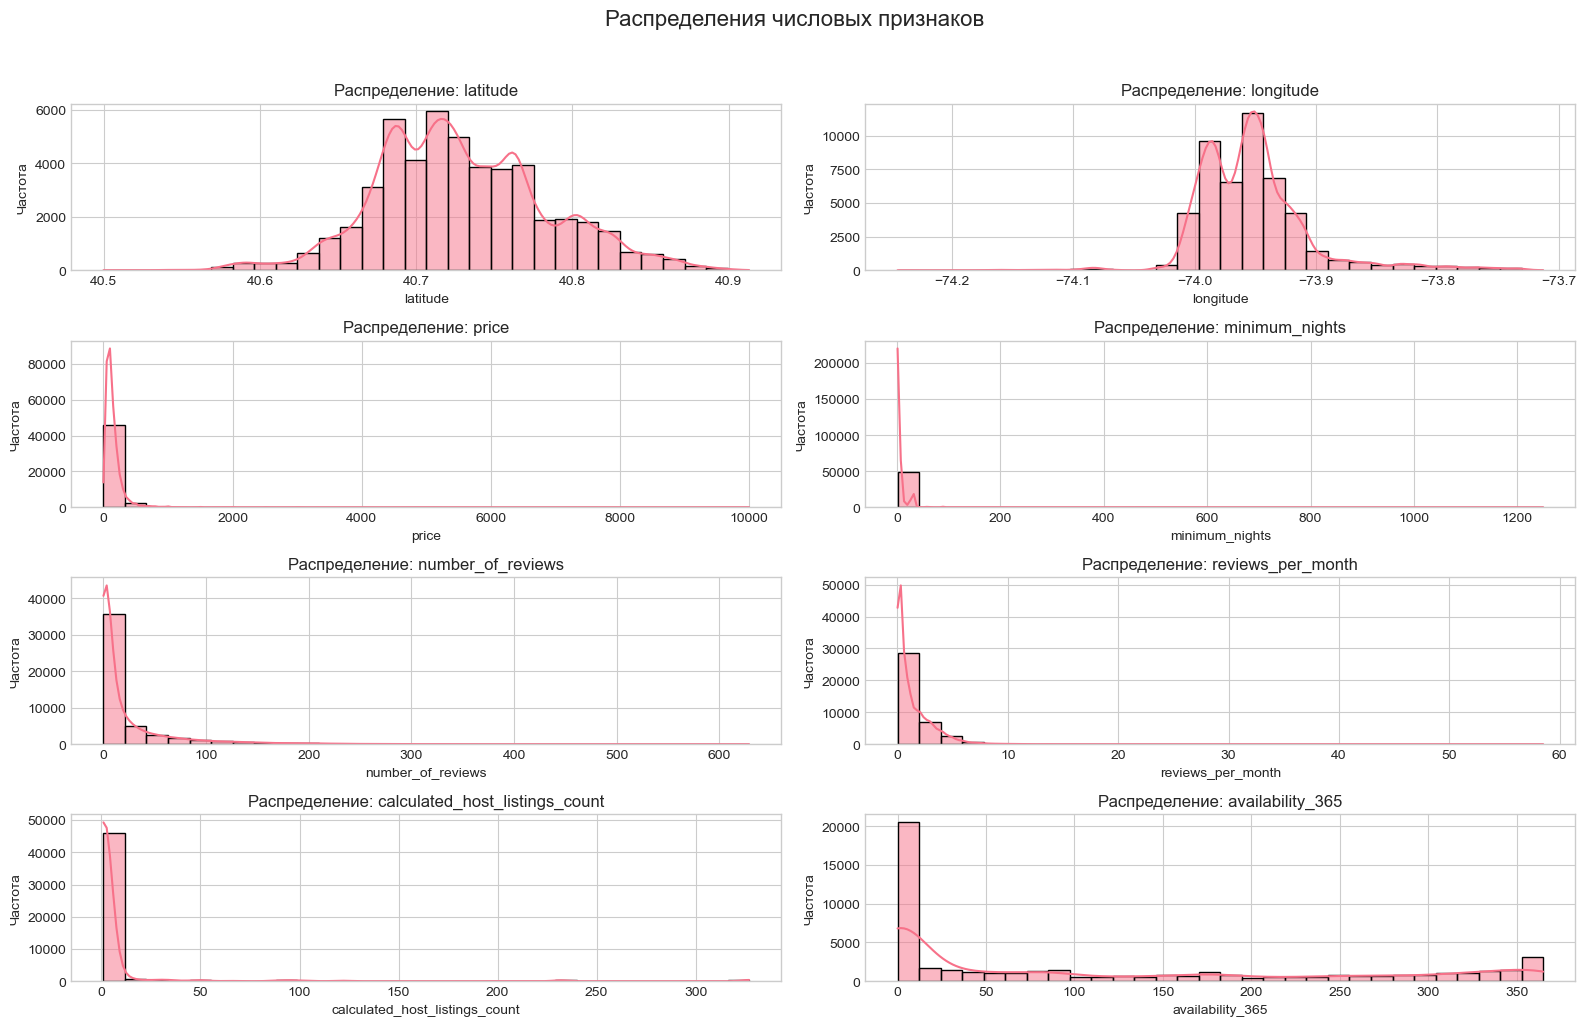

In [22]:
# визуализируйте базовые статистики данных: 
# распределения признаков
fig, axes = plt.subplots(5, 2, figsize=(16, 12))
axes = axes.ravel()
# Список числовых признаков для визуализации
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

for i, col in enumerate(numeric_cols):
    if i < len(axes):
        # Гистограмма с KDE
        sns.histplot(data=df, x=col, kde=True, ax=axes[i], bins=30)
        axes[i].set_title(f'Распределение: {col}', fontsize=12)
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Частота')

# Удаляем пустые подграфики
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Распределения числовых признаков', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


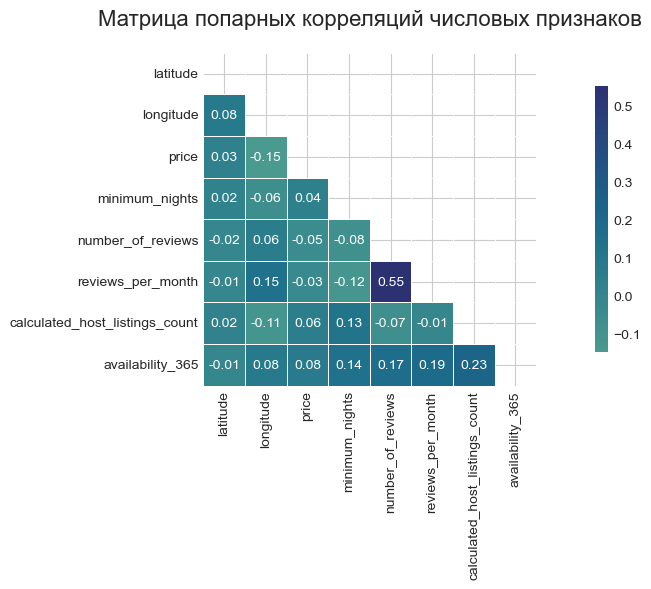

In [23]:
# матрицу попарных корреляций

plt.figure(figsize=(12, 6))
corr_matrix = df[numeric_cols].corr()

# Тепловая карта корреляций
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='crest',
            center=0,
            square=True,
            mask=mask,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8})

plt.title('Матрица попарных корреляций числовых признаков', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

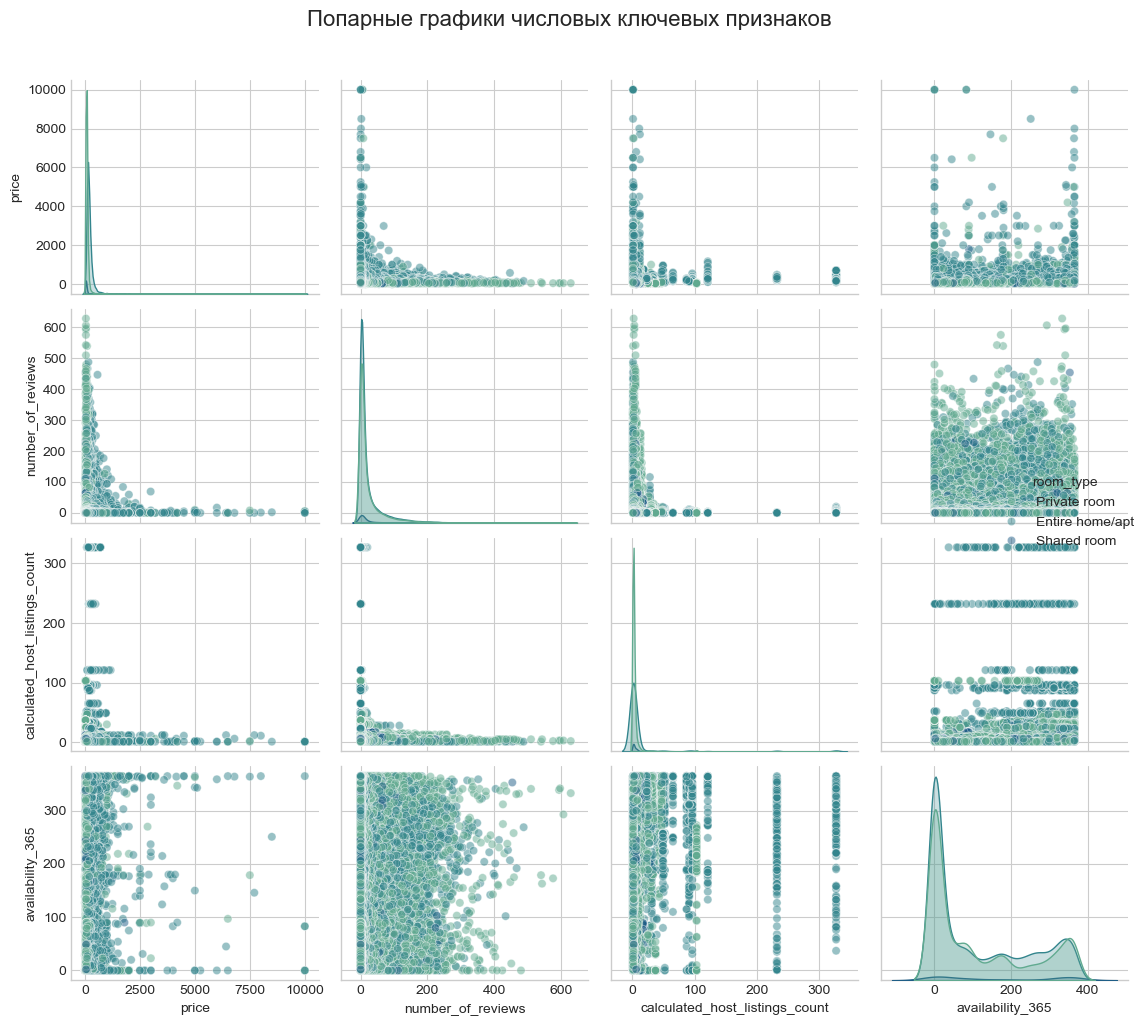

In [45]:
cols_for_pairplots = ['price', 'room_type', 'number_of_reviews', 
                             'calculated_host_listings_count', 'availability_365']
sns.pairplot(df[cols_for_pairplots], diag_kind='kde', palette='crest', hue='room_type', plot_kws={'alpha': 0.5})
plt.suptitle('Попарные графики ключевых признаков', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()


In [36]:
# Комплексная предобработка данных Airbnb
df_processed = df.copy()
print(f"Исходный размер данных: {df_processed.shape}")

# Анализ пропусков
missing_before = df_processed.isnull().sum()
print(missing_before[missing_before > 0])

Исходный размер данных: (48895, 11)
reviews_per_month    10052
dtype: int64


In [37]:
# Обработка reviews_per_month
# Логика: если количество отзывов = 0, то и reviews_per_month должен быть 0
mask_zero_reviews = df_processed['number_of_reviews'] == 0
df_processed.loc[mask_zero_reviews, 'reviews_per_month'] = df_processed.loc[mask_zero_reviews, 'reviews_per_month'].fillna(0)

# Для оставшихся пропусков используем медиану по группе (тип комнаты + район)
remaining_missing = df_processed['reviews_per_month'].isnull()
if remaining_missing.any():
    # Группировка по room_type и neighbourhood_group
    grouped_median = df_processed.groupby(['room_type', 'neighbourhood_group'])['reviews_per_month'].transform('median')
    df_processed['reviews_per_month'] = df_processed['reviews_per_month'].fillna(grouped_median)
        
# Если остались пропуски, заполняем общей медианой
df_processed['reviews_per_month'] = df_processed['reviews_per_month'].fillna(df_processed['reviews_per_month'].median())
    
print(f"\nПропуски после обработки:")
print(df_processed.isnull().sum()[df_processed.isnull().sum() > 0] if any(df_processed.isnull().sum() > 0) else "Пропусков нет")




Пропуски после обработки:
Пропусков нет


In [24]:
# Функция для обработки выбросов методом IQR
def handle_outliers_iqr(df, column, factor=1.5, method='cap'):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - factor * IQR
    upper_bound = Q3 + factor * IQR
    
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    print(f"  {column}: {len(outliers)} выбросов ({len(outliers)/len(df)*100:.1f}%)")
    
    if method == 'cap':
        # Винсоризация (ограничение)
        df[column] = df[column].clip(lower_bound, upper_bound)
    elif method == 'remove':
        # Удаление выбросов
        df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    
    return df

# Обработка выбросов в ключевых признаках
numeric_cols_for_outliers = ['price', 'minimum_nights', 'number_of_reviews', 
                             'calculated_host_listings_count', 'availability_365']

print("Анализ выбросов:")
for col in numeric_cols_for_outliers:
    df_processed = handle_outliers_iqr(df_processed, col, factor=2.0, method='cap')

    

Анализ выбросов:


NameError: name 'df_processed' is not defined

In [23]:

# Специфичная обработка для price (не может быть отрицательной или нулевой)
df_processed = df_processed[df_processed['price'] > 0]
print(f"\nУдалены записи с price <= 0")

# Ограничение minimum_nights разумными пределами
df_processed.loc[df_processed['minimum_nights'] > 180, 'minimum_nights'] = 180
print(f"Ограничены minimum_nights > 180")

NameError: name 'df_processed' is not defined

In [22]:
# работа с категориальными переменными
categorical_cols = ['neighbourhood_group', 'neighbourhood', 'room_type']
print("Уникальные значения категориальных признаков:")
for col in categorical_cols:
    unique_vals = df_processed[col].nunique()
    print(f"  {col}: {unique_vals} уникальных значений")
    if unique_vals <= 10:
        print(f"    {df_processed[col].unique()}")


Уникальные значения категориальных признаков:


NameError: name 'df_processed' is not defined

In [21]:
from tqdm import tqdm
import time

for i in tqdm(range(100)):
    # Simulate some work
    time.sleep(0.01)

100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [00:01<00:00, 93.98it/s]
